In [ ]:
#把csv檔案中不是 600+0 180+2的時間去掉，產生兩組新的csv分別放10分鐘的資料跟3+2的資料

In [1]:
import csv
import chess
import chess.pgn
import io
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    r2_score,
    silhouette_score,
)
from warnings import filterwarnings
from io import StringIO

In [2]:
print(chess.__version__)

1.10.0


In [3]:
chunks = [f"chunk_{i}" for i in range(1, 301)]

In [4]:
pgn_file = "CHUNK/chunk_1.pgn"

C:\Users\user\AppData\Local\Temp\ipykernel_18776\703241912.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_control_counts.index, y=time_control_counts.values, palette="viridis")


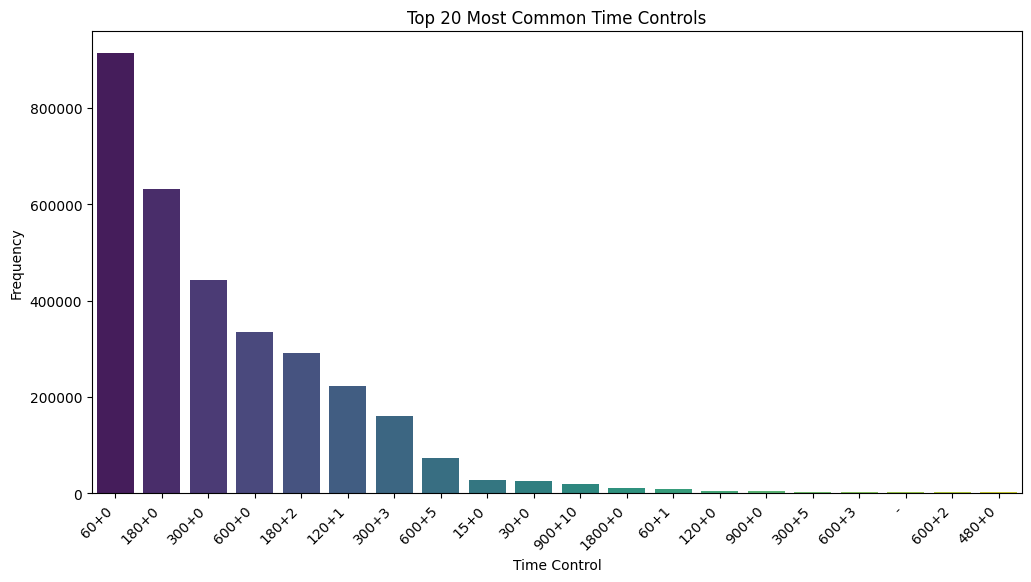

In [5]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# 設定 CSV 檔案的資料夾路徑
csv_folder = "CSV/*.csv"

# 取得所有 CSV 檔案
csv_files = glob.glob(csv_folder)

# 建立空的列表來存儲 TimeControl 數據
all_time_controls = []

for file in csv_files:
    df = pd.read_csv(file)
    
    # 確保 "TimeControl" 欄位存在並讀取數據
    if "TimeControl" in df.columns:
        all_time_controls.extend(df["TimeControl"].dropna().tolist())

# 轉為 DataFrame 並統計出現次數
time_control_counts = pd.Series(all_time_controls).value_counts()

# 只顯示前 20 種最常見的 TimeControl
top_n = 20
time_control_counts = time_control_counts.head(top_n)

# 繪製長條圖
plt.figure(figsize=(12, 6))
sns.barplot(x=time_control_counts.index, y=time_control_counts.values, palette="viridis")

plt.xlabel("Time Control")
plt.ylabel("Frequency")
plt.title(f"Top {top_n} Most Common Time Controls")
plt.xticks(rotation=45, ha='right')  # 旋轉 x 軸標籤，避免重疊
plt.show()


In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# 設定 CSV 檔案的資料夾路徑
csv_folder = "CSV/*.csv"

# 取得所有 CSV 檔案
csv_files = glob.glob(csv_folder)

# 建立空的列表來存儲 TimeControl 數據
all_time_controls = []

for file in csv_files:
    df = pd.read_csv(file)
    
    # 確保 "TimeControl" 欄位存在並讀取數據
    if "TimeControl" in df.columns:
        all_time_controls.extend(df["TimeControl"].dropna().tolist())

# 轉為 DataFrame 並統計出現次數
time_control_counts = pd.Series(all_time_controls).value_counts()

# 僅保留 "600+0" 和 "180+2"
filtered_counts = time_control_counts[time_control_counts.index.isin(["600+0", "180+2"])]

# 繪製長條圖
plt.figure(figsize=(6, 4))
sns.barplot(x=filtered_counts.index, y=filtered_counts.values, palette="viridis")

plt.xlabel("Time Control")
plt.ylabel("Frequency")
plt.title("Frequency of Selected Time Controls")
plt.show()

In [7]:
import pandas as pd
import glob
import os

# 設定 CSV 檔案的資料夾路徑
csv_folder = "CSV/*.csv"

# 取得所有 CSV 檔案
csv_files = glob.glob(csv_folder)

# 輸出資料夾名稱
output_folder_600 = "Filtered_CSV/600+0"
output_folder_180 = "Filtered_CSV/180+2"

# 確保輸出資料夾存在
os.makedirs(output_folder_600, exist_ok=True)
os.makedirs(output_folder_180, exist_ok=True)

# 指定要保留的 TimeControl 值
valid_time_controls = ["600+0", "180+2"]

for file in csv_files:
    df = pd.read_csv(file)

    # 確保 "TimeControl" 欄位存在
    if "TimeControl" in df.columns:
        # 過濾出符合條件的數據
        df_600 = df[df["TimeControl"] == "600+0"]
        df_180 = df[df["TimeControl"] == "180+2"]

        # 生成新的檔案名稱
        filename = os.path.basename(file)  # 取得原始檔案名稱
        output_file_600 = os.path.join(output_folder_600, f"600+0_{filename}")
        output_file_180 = os.path.join(output_folder_180, f"180+2_{filename}")

        # 儲存過濾後的 CSV（如果有數據才儲存）
        if not df_600.empty:
            df_600.to_csv(output_file_600, index=False)

        if not df_180.empty:
            df_180.to_csv(output_file_180, index=False)

print("過濾與儲存完成！🚀")


過濾與儲存完成！🚀
